Practical: Classification using Deep neural network (Any One from the following):
1. Multiclass classification using Deep Neural Networks: Example: Use the OCR letter
recognition datasethttps://archive.ics.uci.edu/ml/datasets/letter+recognition
2. Binary classification using Deep Neural Networks Example: Classify movie reviews into
positive" reviews and "negative" reviews, just based on the text content of the reviews.
Use IMDB dataset

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases" + "/letter-recognition/letter-recognition.data"


In [ ]:
df = pd.read_csv(url, header=None)

X = df.iloc[:, 1:]
X = X / 15.0
y = df.iloc[:, 0]
y = pd.get_dummies(y)
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.3, random_state=42
)

In [ ]:
model = Sequential([
Dense(64, input_dim=16, activation='relu'),
Dense(32, activation='relu'), Dense(26, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy']
)

In [ ]:
history = model.fit(
X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=32
)

Epoch 1/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.1201 - loss: 3.0523 - val_accuracy: 0.4500 - val_loss: 2.0804
Epoch 2/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4856 - loss: 1.8987 - val_accuracy: 0.5708 - val_loss: 1.5438
Epoch 3/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5960 - loss: 1.4808 - val_accuracy: 0.6205 - val_loss: 1.3696
Epoch 4/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6364 - loss: 1.2976 - val_accuracy: 0.6388 - val_loss: 1.2504
Epoch 5/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6582 - loss: 1.2158 - val_accuracy: 0.6793 - val_loss: 1.1784
Epoch 6/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6768 - loss: 1.1589 - val_accuracy: 0.6945 - val_loss: 1.1210
Epoch 7/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6976 - loss: 1.0818 - val_accuracy: 0.6900 - val_loss: 1.0655
Epoch 8/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7071 - loss: 1.0521 - val_accu

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test accuracy:", test_acc)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.figure(figsize=(10, 5))

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8915 - loss: 0.3637
Test accuracy: 0.8871666789054871


<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

/tmp/ipython-input-1417449652.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo" (-> color='b'). The keyword argument will take precedence.
  plt.plot(epochs, loss, 'bo', label='Training loss',color='red')
/tmp/ipython-input-1417449652.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, val_loss, 'b', label='Validation loss',color='red')


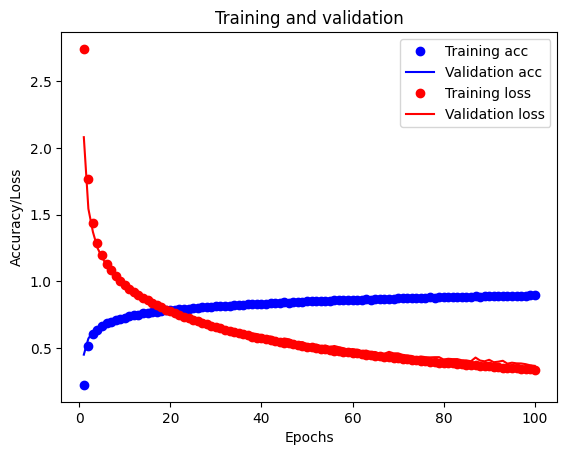

(Text(24.000000000000007, 0.5, 'Accuracy/Loss'),
 None)

In [ ]:
# Plot training and validation Accuracy & Loss
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.plot(epochs, loss, 'bo', label='Training loss',color='red')
plt.plot(epochs, val_loss, 'b', label='Validation loss',color='red')
plt.title('Training and validation'), plt.xlabel('Epochs')
plt.ylabel('Accuracy/Loss'), plt.legend(), plt.show()

In [ ]:
# Make predictions on test data
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(np.array(y_test), axis=1)

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
# Calculate prediction accuracy
test_acc = np.mean(y_pred == y_true), print("Test accuracy:", test_acc)

Test accuracy: 0.8871666789054871


In [ ]:
# Create a confusion matrix
conf_mat = np.zeros((26, 26), dtype=int)
for i in range(len(y_true)):
    conf_mat[y_true[i], y_pred[i]] += 1

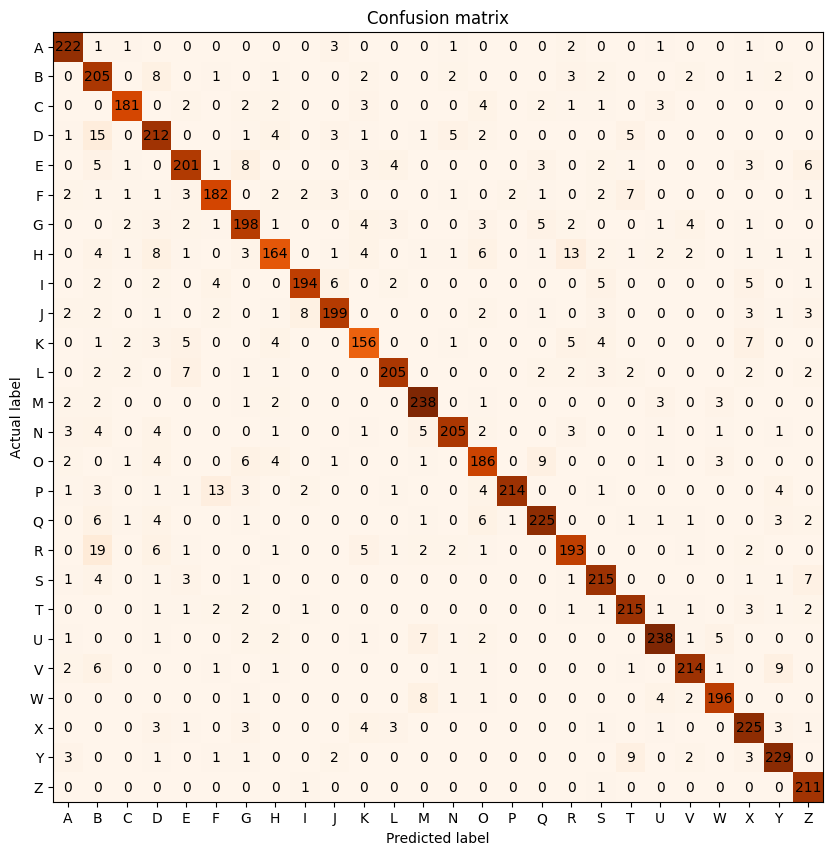

In [ ]:
# Visualize prediction accuracy
plt.figure(figsize=(10, 10))
plt.imshow(conf_mat, cmap='Oranges')
plt.xticks(range(26), [chr(ord('A')+i) for i in range(26)])
plt.yticks(range(26), [chr(ord('A')+i) for i in range(26)])
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.title('Confusion matrix')
for i in range(26):
    for j in range(26):
        plt.text(
            j, i, conf_mat[i, j], ha='center', va='center',
            color='white' if conf_mat[i, j] > len(y_true)*0.05 else 'black'
        )
plt.show()

In [ ]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
# Load the dataset
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Pad the sequences to the same length
X_train = pad_sequences(X_train, maxlen=100)
X_test = pad_sequences(X_test, maxlen=100)

In [ ]:
from keras.layers import Embedding, Conv1D, MaxPooling1D, GlobalMaxPooling1D

maxlen = 100 # Defining maxlen based on previous pad_sequences call
bmodel = Sequential([
Embedding(input_dim=10000, output_dim=32),
Conv1D(32, 7, activation='relu'), MaxPooling1D(5),
Conv1D(32, 7, activation='relu'), GlobalMaxPooling1D(),
Dense(1, activation='sigmoid')
])
bmodel.compile(
optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc']
)

In [ ]:
history = bmodel.fit(
X_train, y_train, epochs=16, batch_size=128, validation_split=0.2
)

Epoch 1/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - acc: 0.5324 - loss: 0.6861 - val_acc: 0.7378 - val_loss: 0.5224
Epoch 2/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - acc: 0.7779 - loss: 0.4631 - val_acc: 0.8062 - val_loss: 0.4113
Epoch 3/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - acc: 0.8490 - loss: 0.3507 - val_acc: 0.7980 - val_loss: 0.4481
Epoch 4/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - acc: 0.8813 - loss: 0.2890 - val_acc: 0.8206 - val_loss: 0.3953
Epoch 5/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - acc: 0.8963 - loss: 0.2579 - val_acc: 0.8232 - val_loss: 0.4016
Epoch 6/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - acc: 0.9148 - loss: 0.2218 - val_acc: 0.8258 - val_loss: 0.4151
Epoch 7/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - acc: 0.9346 - loss: 0.1801 - val_acc: 0.8262 - val_loss: 0.4315
Epoch 8/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - acc: 0.9502 - loss: 0.1491 - val_acc: 0.7960 - val_loss: 0.6069
Epoch 9/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms

In [ ]:
score = bmodel.evaluate(X_test, y_test)
print("Test loss:", score[0])
print("Test accuracy:", score[1])
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - acc: 0.8116 - loss: 0.9862
Test loss: 0.9931706786155701
Test accuracy: 0.8085600137710571


/tmp/ipython-input-640664459.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo" (-> color='b'). The keyword argument will take precedence.
  plt.plot(epochs, loss, 'bo', label='Training loss', color='red')
/tmp/ipython-input-640664459.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, val_loss, 'b', label='Validation Loss', color='red')


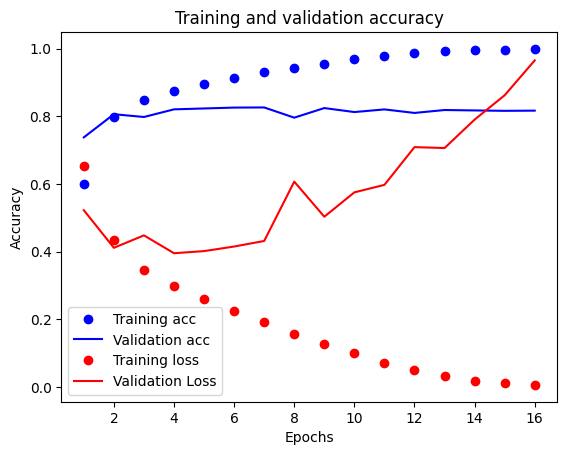

(Text(0.5, 24.0, 'Epochs'),
 Text(24.000000000000007, 0.5, 'Accuracy'),
 None)

In [ ]:
# Plot the training and validation accuracy & loss
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.plot(epochs, loss, 'bo', label='Training loss', color='red')
plt.plot(epochs, val_loss, 'b', label='Validation Loss', color='red')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs'), plt.ylabel('Accuracy'), plt.legend(), plt.show()